# cellAdmix Python standalone Xenium example

This notebook illustrates the standalone Python API on the 10x Genomics Xenium human pancreas membrane-staining dataset. The workflow mirrors the R example: construct a dataset object, fit molecular NMF factors, score likely admixture using the membrane image, inspect factor/source/target evidence, render molecule-level example cells, and write corrected counts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from celladmix import CellAdmix, annotation_knn_purity, read_annotation, plot_spatial

## Inputs

Download the Xenium bundle from the original [10x Genomics dataset page](https://www.10xgenomics.com/datasets/ffpe-human-pancreas-with-xenium-multimodal-cell-segmentation-1-standard) and expand it into a local folder named `data`. The bundle zip can also be downloaded with:

```bash
curl -O https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_human_Pancreas_FFPE/Xenium_V1_human_Pancreas_FFPE_outs.zip
```

Also create an `annotations` folder and download the example annotation files from <http://pklab.org/peterk/cellAdmix/examples/pancreas_377/annotations>. These quick annotations are only for illustration; in a real analysis, use your own cell-type and tissue-region labels.

In [2]:
data_dir = Path("data")
annotation_file = Path("annotations/annotation.csv.gz")
domain_file = Path("annotations/domain_annotation.csv.gz")
output_dir = Path("out_python")

cell_meta = pd.read_csv(annotation_file)
domain_meta = pd.read_csv(domain_file)
annotation = read_annotation(cell_meta, annotation_col="merged_annotation")
annotation.value_counts()

merged_annotation
Exocrine epithelial        36329
Ductal/tumor epithelial    29986
Fibroblast / CAF           28366
Immune                     19251
Endothelial                 7026
Mural / pericyte            2553
Endocrine                   2212
Name: count, dtype: int64

`CellAdmix` records the source bundle, output/cache location, annotation, and default thread count. The constructor validates configuration but does not load all molecules into Python memory.

In [3]:
ds = CellAdmix(data_dir, output_dir=output_dir, annotation=annotation, num_threads=10)
ds

CellAdmix(format='xenium', source='data', output_dir='out_python', annotation=7 labels, num_threads=10)

## Fit Factors

The fit stage constructs neighborhood count vectors, fits NMF factors, projects/smooths molecule assignments, and writes reusable run artifacts. By default, the factor rank is derived from the number of annotated cell types and at least 10 independent NMF restarts are run. The NMF variant is chosen to match the scoring method: this membrane-stained dataset will be cleaned with membrane scoring, which removes the most admixture when paired with the sparse `invsqrt_kl` factorization (see [docs/benchmarks.md](../../docs/benchmarks.md)).

In [4]:
fit = ds.fit(nmf_variant="invsqrt_kl", verbose=True)
fit

[INFO 11:07:49 +0.041s] Loaded store metadata: 6186500 molecules, 140335 cells, 377 genes (0.035s)
[INFO 11:07:49 +0.046s] Resolved ncv_k=20 automatically (377 genes present, median 35 molecules/cell) (0.000s)
[INFO 11:07:49 +0.074s] Selected store-backed training queries: 10000 rows (0.028s)


[INFO 11:07:50 +1.724s] Built store-backed sampled NCV matrix (1.649s)


[INFO 11:07:54 +4.902s] Fit store-backed sparse KL NMF [invsqrt_kl] [cluster init] [ordered by training W mass] (selected run 1/10, seed=1, objective_mean=475037, objective_sd=2759.4, mean_matched_ownership_cor=0.461, stable_factors=5/9) (3.175s)


[INFO 11:08:05 +16.582s] Processed molecule blocks [molecule_scoring=gene_loadings] [load=1.257s, project=0.391s, smooth=3.345s, write=5.830s] (11.665s)
[INFO 11:08:05 +16.764s] Finished cell-blocked store-backed fit (16.764s)


CellAdmixFit(run_path='out_python/runs/fit_rank9_invsqrt_kl', n_factors=9, n_cells=140335)

Top factor loadings give a first-pass interpretation of each molecular factor.

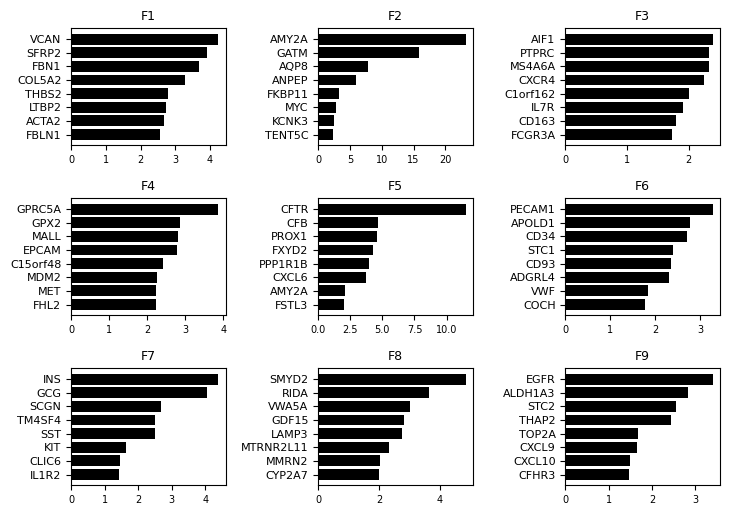

In [5]:
fit.plot_loadings();

The stability plot summarizes multiseed NMF behavior: important factors should ideally have high restart stability.

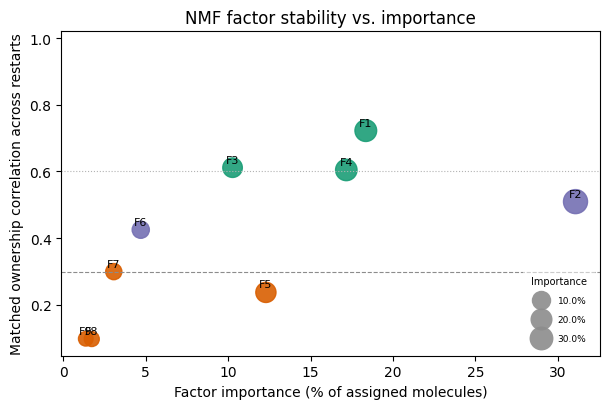

In [6]:
fit.plot_stability();

## Admixture Audit

Before interpreting factors, the audit estimates how much admixture the
dataset carries and between which cell types, using only the spatial
exposure structure: source-marker content in target cells rises with the
number of source-type neighbor cells, while unexposed target cells provide
an internal negative control. The map shows each detected pair's estimated
admixture rate — the percent of the target type's molecules that leaked in
from the source, extrapolated from a directly measured (and conservative)
marker excess.

In [7]:
audit = fit.audit_admixture()
audit_pairs = audit.pairs(detected_only=True)
audit_pairs.sort_values("admixed_molecules", ascending=False).head(8)

,source,target,excess,excess_strict,pct_of_exposed,q_value,detected,n_exposed,n_reference,n_markers,n_strict
18,Exocrine epithelial,Ductal/tumor epithelial,362132,221588.0,49.336088,0.0,True,13207,16779,20,3
22,Exocrine epithelial,Immune,46804,44130.0,23.777808,0.0,True,6409,12842,20,5
20,Exocrine epithelial,Endothelial,46048,44347.0,27.581274,0.0,True,3668,3358,20,6
21,Exocrine epithelial,Fibroblast / CAF,38961,38044.0,17.476708,0.0,True,5312,23054,20,8
28,Fibroblast / CAF,Immune,38636,5717.0,9.333381,0.0,True,16195,3056,20,2
34,Immune,Fibroblast / CAF,32837,NaN,3.504904,0.0,True,24683,3683,20,0
24,Fibroblast / CAF,Ductal/tumor epithelial,24080,14554.0,2.361001,0.0,True,15882,14104,20,9
26,Fibroblast / CAF,Endothelial,15510,4110.0,6.686391,0.0,True,5170,1856,20,3


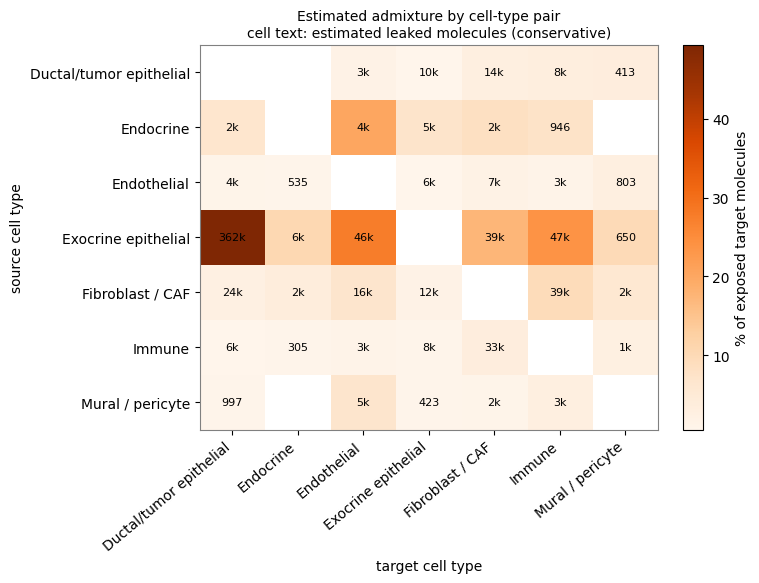

In [8]:
audit.plot_map();

The default exposure view pools all detected pairs into one cumulative
profile (error bars are 95% Poisson intervals); passing a specific pair
shows that pair's own profile.

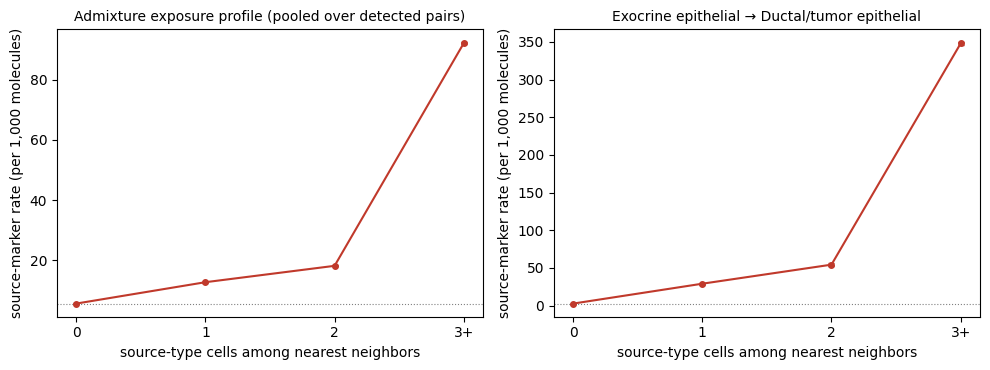

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
audit.plot_exposure(ax=axes[0])
audit.plot_exposure("Exocrine epithelial", "Ductal/tumor epithelial", ax=axes[1])
fig.tight_layout()

## Factor Source Prior

Top loadings are useful, but source calls should emphasize genes that actually distinguish annotated cell types. `score_factor_sources()` builds pseudobulk cell-type profiles from the original counts, estimates one-versus-rest marker weights, and compares each NMF factor against those weighted marker signatures. This is a diagnostic source prior only; the membrane score below is still run independently.

In [10]:
factor_source_score = fit.score_factor_sources()
factor_source_score.annotation()

,factor,factor_label,source_cell_type,score,margin,called
0,1,F1,Fibroblast / CAF,0.788827,0.506817,True
1,2,F2,Exocrine epithelial,0.704775,0.691309,True
2,3,F3,Immune,0.867795,0.841544,True
3,4,F4,Ductal/tumor epithelial,0.788961,0.740972,True
4,5,F5,<NA>,0.149906,0.016494,False
5,6,F6,Endothelial,0.743954,0.694315,True
6,7,F7,Endocrine,0.735912,0.672471,True
7,8,F8,<NA>,0.085510,0.037530,False
8,9,F9,<NA>,0.120834,0.058818,False


In this table, `score` is the marker-weighted similarity between a factor and the best matching cell type. `margin` is the best score minus the second-best score for that factor; larger margins indicate more specific source evidence. `called` indicates whether the best cell type passed both thresholds used for source-prior annotation.

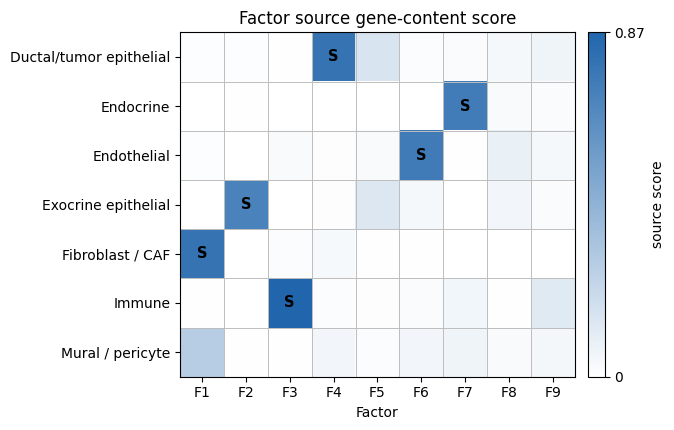

In [11]:
factor_source_score.plot_heatmap();

The next plot shows the cell-type marker genes that most strongly support each factor's best source call.

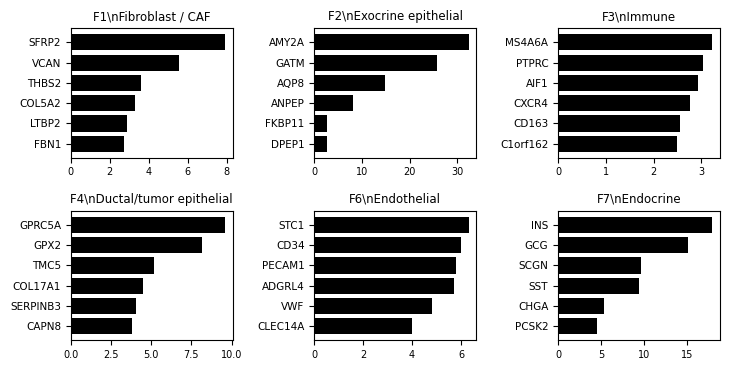

In [12]:
factor_source_score.plot_top_genes();

## Tissue Context

For side visualizations, merge cellAdmix cell-level factor summaries with the supplied cell-type and coarse tissue-domain annotations. These annotations are not used by the plotting helper except as columns in the displayed table.

In [13]:
cell_factors = fit.cell_factors()
cell_spatial = cell_factors.merge(cell_meta[["cell_id", "merged_annotation"]], on="cell_id", how="inner")
cell_spatial = cell_spatial.merge(domain_meta[["cell_id", "domain_label"]], on="cell_id", how="inner")
cell_spatial.head()

,cell_idx,cell_id,x,y,z,transcript_count,dominant_factor,dominant_fraction,factor_1_fraction,factor_2_fraction,factor_3_fraction,factor_4_fraction,factor_5_fraction,factor_6_fraction,factor_7_fraction,factor_8_fraction,factor_9_fraction,merged_annotation,domain_label
0,0,fdhdaeok-1,190.721115,1876.243652,0.0,28,3,0.928571,0.000000,0.0,0.928571,0.035714,0.00000,0.000000,0.0,0.035714,0.000000,Immune,tumor
1,1,fdhenklc-1,206.656555,1849.096558,0.0,13,4,0.538462,0.230769,0.0,0.000000,0.538462,0.00000,0.076923,0.0,0.076923,0.076923,Fibroblast / CAF,tumor
2,2,fdhdfnfb-1,208.478104,1891.373291,0.0,44,1,0.954545,0.954545,0.0,0.000000,0.045455,0.00000,0.000000,0.0,0.000000,0.000000,Fibroblast / CAF,tumor
3,3,fdhenili-1,213.458740,1824.258179,0.0,15,1,0.400000,0.400000,0.0,0.333333,0.000000,0.00000,0.000000,0.0,0.000000,0.266667,Immune,tumor
4,4,fdhebggg-1,211.174698,1859.880737,0.0,201,1,0.940299,0.940299,0.0,0.004975,0.009950,0.00995,0.004975,0.0,0.004975,0.024876,Fibroblast / CAF,tumor


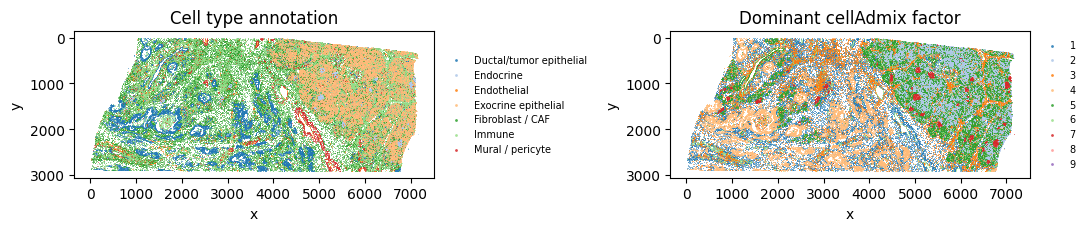

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
plot_spatial(cell_spatial, color_by="merged_annotation", title="Cell type annotation", ax=axes[0], s=0.25)
plot_spatial(cell_spatial, color_by="dominant_factor", title="Dominant cellAdmix factor", ax=axes[1], s=0.25)
plt.show()

## Diagnostic Setup

Scoring and correction below are run for all annotated cell types. The example-cell panels are restricted to two illustrative target cell types so the notebook stays readable. Marker genes are used only to slightly emphasize selected molecules in the example-cell overlays.

In [15]:
diagnostic_cell_types = ["Endothelial", "Immune"]
ductal_tumor_markers = ["GPRC5A", "MALL", "FHL2", "EPCAM", "GPX2", "MET", "SERPINB3", "KRT7"]
endocrine_exocrine_markers = ["AMY2A", "AQP8", "ANPEP", "CFTR", "INS", "GCG", "SST", "CHGA", "SCGN"]
source_marker_genes = sorted(set(ductal_tumor_markers + endocrine_exocrine_markers))
source_marker_genes

['AMY2A',
 'ANPEP',
 'AQP8',
 'CFTR',
 'CHGA',
 'EPCAM',
 'FHL2',
 'GCG',
 'GPRC5A',
 'GPX2',
 'INS',
 'KRT7',
 'MALL',
 'MET',
 'SCGN',
 'SERPINB3',
 'SST']

## Membrane Scoring

Membrane scoring asks whether target-cell molecules assigned to each factor are enriched along membrane-stain paths facing candidate source cell types. The score object stores pair-level and summarized evidence; it does not modify molecules. The membrane heatmap below overlays the gene-content source prior: `S` marks the membrane/spatial source, `G` marks the gene-content source, `SG` marks agreement, separate `S` and `G` labels in the same factor column indicate source conflict, and `*` marks a cleanup target.

[INFO 11:08:31 +5.108s] Starting membrane test: molecules=6186500, cells=140335 (0.000s)
[INFO 11:08:31 +5.109s] Opened membrane image: width=34155, height=13770 (0.000s)


[INFO 11:08:32 +5.357s] Prepared membrane data: cell_types=7, factors=9, active_cells=140335, typed_active_cells=125723 (0.248s)


[INFO 11:08:33 +6.552s] Discovered membrane candidates: pairs=18940 (1.194s)


[INFO 11:10:15 +108.340s] Scored membrane candidates: score_rows=35377 (101.789s)
[INFO 11:10:15 +108.346s] Summarized membrane scores: summaries=380 (0.005s)
[INFO 11:10:15 +108.346s] Finished membrane test: summaries=380 (103.237s)


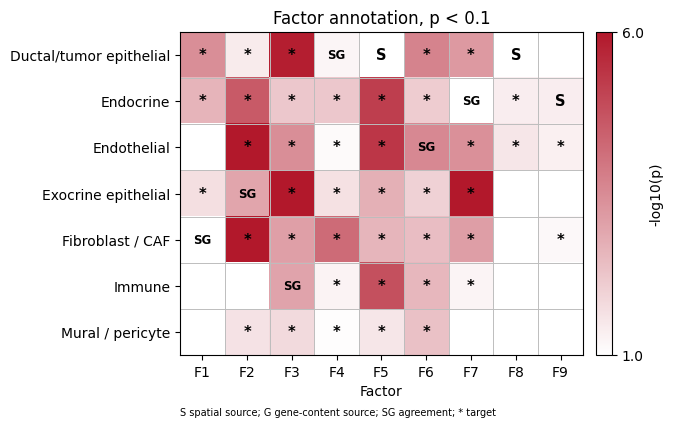

In [16]:
p_thresh = 0.1
membrane_score = fit.score_membrane(verbose=True)
score_annotation = membrane_score.annotation(p_thresh=p_thresh)
membrane_score.plot_heatmap(p_thresh=p_thresh, source_prior=factor_source_score);

The factor-pair plots show one factor at a time. Columns are candidate source cell types, rows are candidate target cell types, the top row summarizes source evidence, and the main matrix shows signed admixture significance.

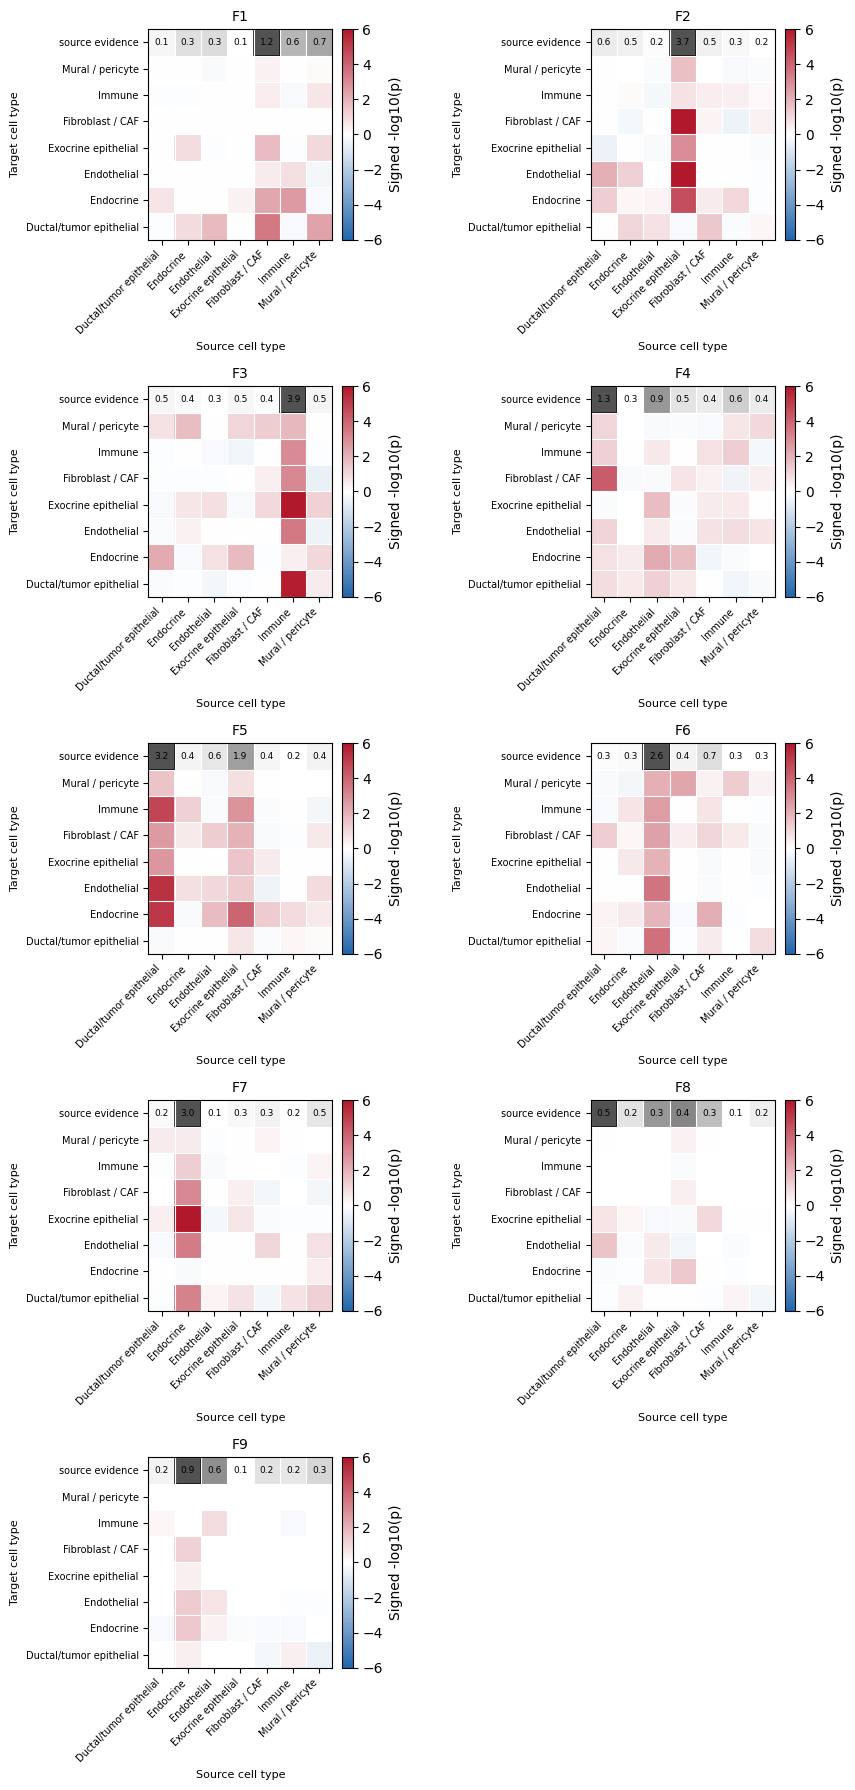

In [17]:
membrane_score.plot_pairs(p_thresh=p_thresh);

Correction rules are derived from the factor annotations. Each rule says that molecules assigned to a factor should be removed from a target cell type; the source cell type is kept as an interpretation of the likely origin.

In [18]:
rules = membrane_score.rules(p_thresh=p_thresh)
rules[["factor", "source_cell_type", "target_cell_type", "p_value", "keep", "native_check"]].head()

,factor,source_cell_type,target_cell_type,p_value,keep,native_check
11,3,Immune,Exocrine epithelial,1.195552e-10,True,pass
6,2,Exocrine epithelial,Fibroblast / CAF,1.439570e-10,True,pass
34,7,Endocrine,Exocrine epithelial,3.075489e-10,True,pass
5,2,Exocrine epithelial,Endothelial,7.702263e-07,True,pass
8,3,Immune,Ductal/tumor epithelial,1.397211e-06,True,pass


## Example Cells

The example-cell overlays show local molecule-level context for selected target cells. The background combines DAPI and membrane crops, the orange contour marks the target cell, blue molecules are native factors for that target cell type, red molecules are the selected top admixture factor, and orange molecules are other non-native factors.

In [19]:
example_cells = membrane_score.examples(rules=rules, score_annotation=score_annotation, cell_data=cell_spatial, targets=diagnostic_cell_types, n_per_target=2)
example_cells[["target_cell", "target_cell_type", "top_admix_factor", "top_admix_source", "top_factor_molecules", "top_factor_fraction"]]

,target_cell,target_cell_type,top_admix_factor,top_admix_source,top_factor_molecules,top_factor_fraction
0,fmennbne-1,Endothelial,7,Endocrine,52.0,0.361111
1,lecoljpk-1,Endothelial,5,Ductal/tumor epithelial,13.0,0.185714
2,eecfaioc-1,Immune,7,Endocrine,19.0,0.157025
3,efnkbnkg-1,Immune,4,Ductal/tumor epithelial,23.0,0.343284


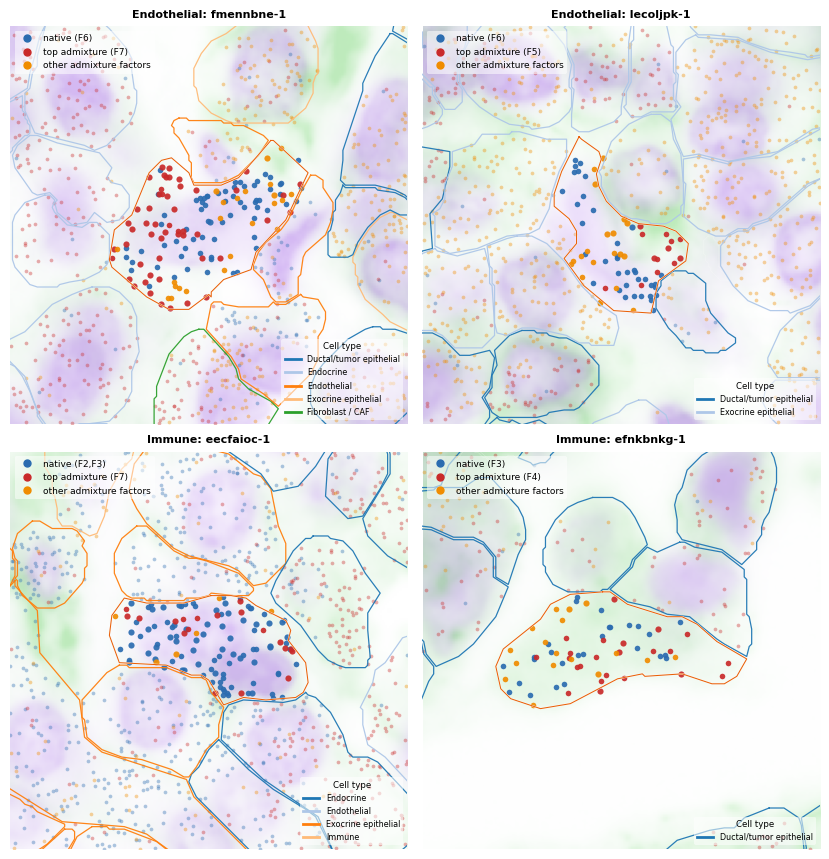

In [20]:

membrane_score.plot_examples(example_cells, score_annotation=score_annotation, cell_data=cell_spatial, markers=source_marker_genes, ncol=2);

## Correction

The correction step applies all membrane-derived rules across all annotated cell types, by default as a molecule-vote ensemble across the fit's NMF restarts (a molecule is removed when at least 30% of the independently scored restarts remove it). It writes a corrected run and can collect corrected counts as a sparse genes-by-cells matrix.

In [21]:
correction = membrane_score.correct(rules=rules, name="membrane_clean")
correction.summary().head()

Ensemble correction over 10 members: molecules removed by >= 3 members (vote >= 0.30) are dropped (1,595,516 molecules).


,cell_type,n_cells,n_modified_cells,fraction_cells_modified,molecules_before,molecules_after,molecules_removed,fraction_molecules_removed,median_removed_per_modified_cell,median_fraction_removed_per_modified_cell
0,all,140335,120290,0.857163,6186500.0,4590984.0,1595516.0,0.257903,8.0,0.181818
1,Ductal/tumor epithelial,29986,29562,0.985860,1918375.0,1360394.0,557981.0,0.290861,12.0,0.196721
2,Endocrine,2212,2190,0.990054,125632.0,96599.0,29033.0,0.231096,10.0,0.204545
3,Endothelial,7026,6908,0.983205,318282.0,211937.0,106345.0,0.334122,10.0,0.271316
4,Exocrine epithelial,36329,35919,0.988714,2085030.0,1474120.0,610910.0,0.292998,13.0,0.214286


The audit verifies the correction against the same exposure
measurements: per-pair cleanup sensitivity, the own-marker false-removal
rate (loss of near-surely-genuine molecules), and a warning for any
detected pair no removal rule covers.

In [22]:
report = audit.evaluate(correction)
report.summary()

/tmp/ipykernel_1506715/346086481.py:1: UserWarning: Detected ~46,804 leaked molecules from Exocrine epithelial into Immune, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_1506715/346086481.py:1: UserWarning: Detected ~15,510 leaked molecules from Fibroblast / CAF into Endothelial, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_1506715/346086481.py:1: UserWarning: Detected ~38,636 leaked molecules from Fibroblast / CAF into Immune, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_1506715/346086481.py:1: UserWarning: Detected ~2,446 leaked molecules from Fibroblast / CAF into Mural / pericyte, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tmp/ipykernel_1506715/346086481.py:1: UserWarning: Detected ~32,837 leaked molecules from Immune into Fibroblast / CAF, but no removal rule covers this pair
  report = audit.evaluate(correction)
/tm

{'detected_pairs': 39,
 'estimated_leaked_molecules': 729488,
 'leakage_removed_overall': np.float64(0.6002632530880738),
 'median_pair_sensitivity': 0.9923731688327776,
 'own_marker_false_removal': 0.032547664971763826}

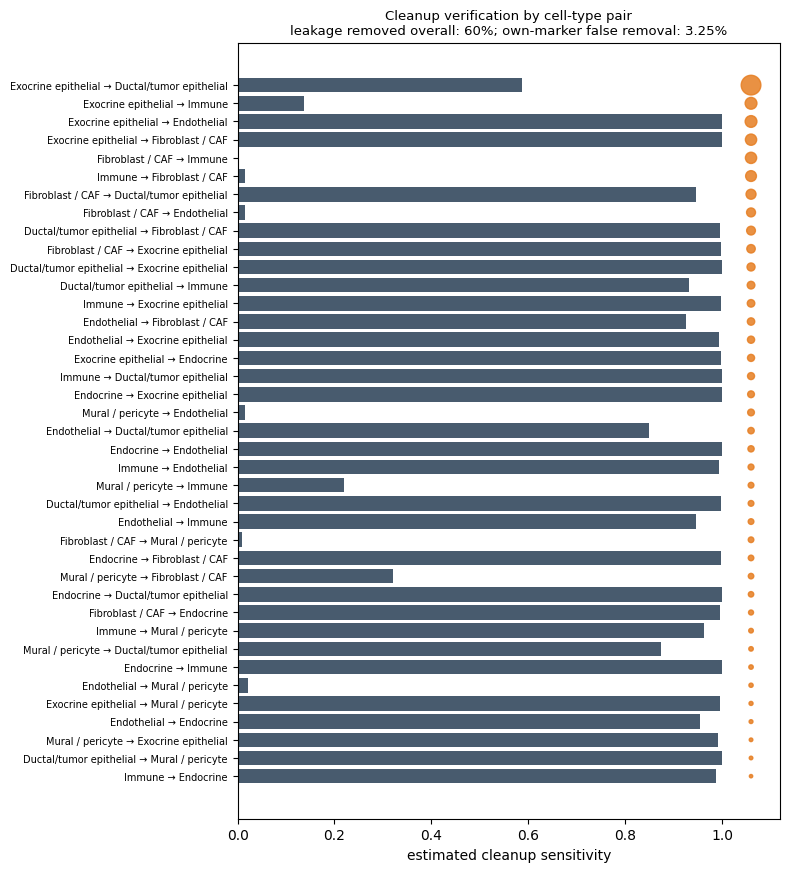

In [23]:
report.plot_cleanup();

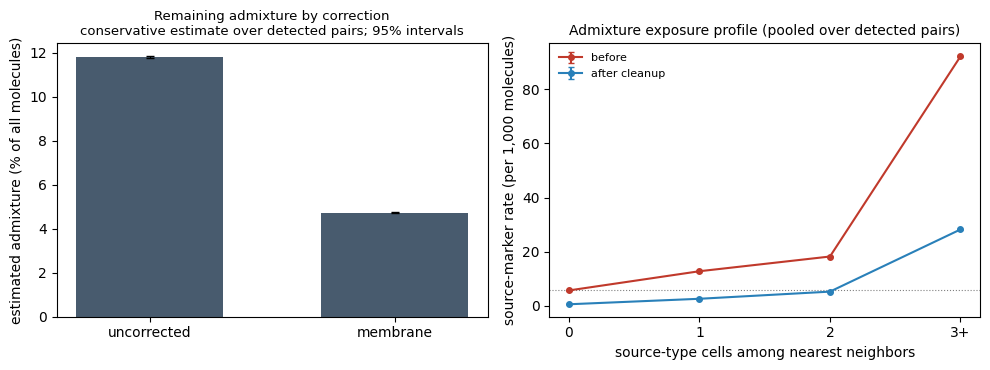

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
audit.plot_remaining({"membrane": correction}, ax=axes[0])
audit.plot_exposure(correction=correction, ax=axes[1])
fig.tight_layout()

The molecule-removal plot is a coarse sanity check showing how many molecules were removed per cell and which cell types were affected most strongly.

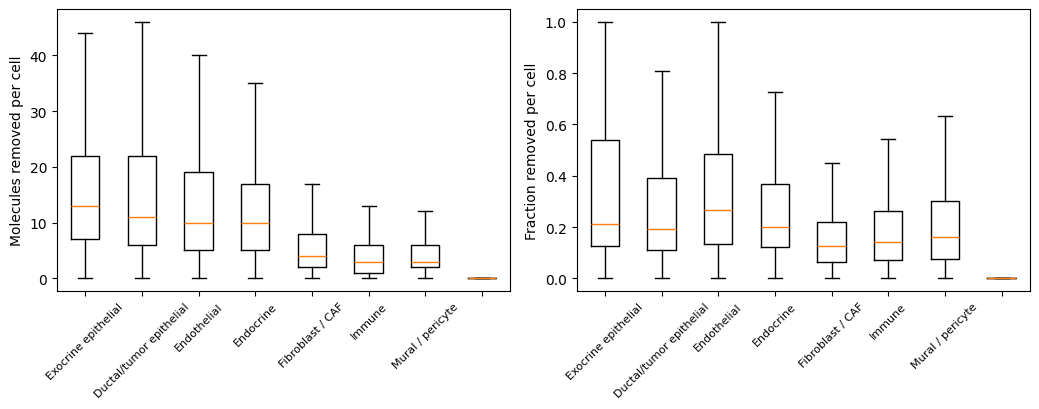

In [25]:
correction.plot_removed_molecules();

A compact cell-state diagnostic asks whether corrected counts improve separation between annotated cell types. Here we use the C++ cell-state UMAP path on a 5,000-cell subset before and after correction, then score local annotation purity in PCA space.

In [26]:
state_cells_max = 5000
original_state = ds.cell_state_umap(cells_max=state_cells_max)
corrected_state = correction.cell_state_umap(annotation=annotation,
    cells_max=state_cells_max, num_threads=ds.num_threads)

state_scores = pd.DataFrame([
    annotation_knn_purity(original_state),
    annotation_knn_purity(corrected_state),
], index=["original", "corrected"])
state_scores

,knn_same_type_fraction,baseline_fraction,normalized_purity
original,0.843107,0.219381,0.799014
corrected,0.938787,0.217922,0.921730


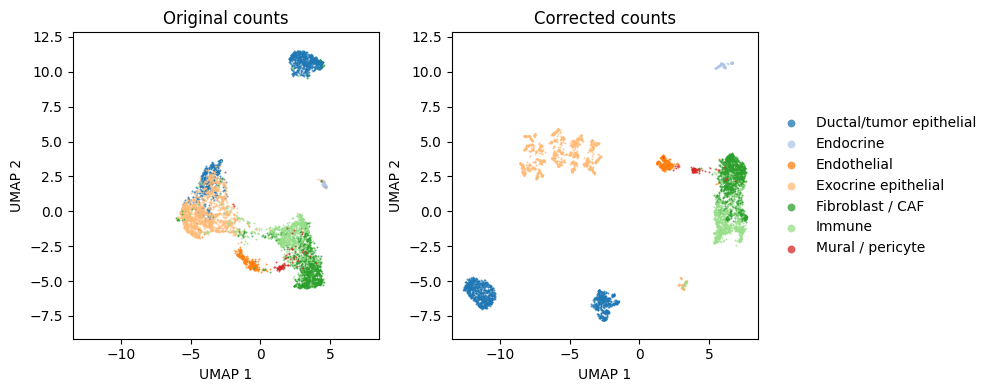

In [27]:
def state_umap_limits(*frames, pad_fraction=0.04):
    x = pd.concat([frame["umap_1"] for frame in frames]).to_numpy(dtype=float)
    y = pd.concat([frame["umap_2"] for frame in frames]).to_numpy(dtype=float)
    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(y.min()), float(y.max())
    span = max(xmax - xmin, ymax - ymin)
    pad = span * pad_fraction
    xmid = (xmin + xmax) / 2
    ymid = (ymin + ymax) / 2
    half = span / 2 + pad
    return (xmid - half, xmid + half), (ymid - half, ymid + half)


def plot_state_umap(frame, title, ax, palette, xlim, ylim):
    for label, color in palette.items():
        mask = frame["cell_type"].astype(str) == label
        if mask.any():
            ax.scatter(frame.loc[mask, "umap_1"], frame.loc[mask, "umap_2"],
                s=2.0, alpha=0.75, linewidths=0, color=color, label=label, rasterized=True)
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")


state_labels = sorted(pd.concat([original_state["cell_type"], corrected_state["cell_type"]]).dropna().astype(str).unique())
colors = plt.get_cmap("tab20").colors
state_palette = {label: colors[i % len(colors)] for i, label in enumerate(state_labels)}

xlim, ylim = state_umap_limits(original_state, corrected_state)
fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.8), constrained_layout=True)
plot_state_umap(original_state, "Original counts", axes[0], state_palette, xlim, ylim)
plot_state_umap(corrected_state, "Corrected counts", axes[1], state_palette, xlim, ylim)
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, markerscale=4)
plt.show()

In [28]:
counts, genes, cells = correction.counts()
counts.shape, genes[:5].tolist(), cells[:5].tolist()

((377, 140335),
 ['LAMP3', 'HES4', 'FBLN1', 'SOX2', 'PDGFRB'],
 ['fdhdaeok-1', 'fdhenklc-1', 'fdhdfnfb-1', 'fdhenili-1', 'fdhebggg-1'])